# E-Commerce EDA and Statistics

This notebook follows the **Olist E-Commerce** steps from the Statistics & Projects handbook.


## Main questions

1. What does one row represent?
2. What are the basic sales, order and customer figures?
3. What is the shape of payment, delivery and review data?
4. Does slower delivery relate to lower review scores?
5. Are late orders more likely to receive low reviews?
6. Who are the best customers using RFM?
7. What share of revenue comes from the top customers?

## 1. Import the libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# These are used only for the required statistical tests
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu

## 2. Load the dataset

In [ ]:
# Upload master_cleaned.csv to the Colab Files panel first

df = pd.read_csv('/content/master_cleaned.csv')

print("Dataset loaded successfully")

Dataset loaded successfully


## 3. Look at the first five rows

In [ ]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,total_payment_value,payment_installments,payment_types_used,total_items,total_freight,total_price,review_score,delivery_days,delay_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149.0,...,38.71,1.0,"credit_card,voucher",1.0,8.72,29.99,4.0,8.0,-8.0,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813.0,...,141.46,1.0,boleto,1.0,22.76,118.70,4.0,13.0,-6.0,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265.0,...,179.12,3.0,credit_card,1.0,19.22,159.90,5.0,9.0,-18.0,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296.0,...,72.20,1.0,credit_card,1.0,27.20,45.00,5.0,13.0,-13.0,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195.0,...,28.62,1.0,credit_card,1.0,8.72,19.90,5.0,2.0,-10.0,False


## 4. Understand the row grain

The **row grain** tells us what one row represents.

Here, each row should represent **one order**.  
We confirm this by comparing the number of rows with the number of unique `order_id` values.

In [ ]:
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))
print("Unique order IDs:", df['order_id'].nunique())

Number of rows: 30385
Number of columns: 22
Unique order IDs: 30385


If the row count and unique order count are equal, then each row represents one order.  
This is important because it prevents revenue from being counted more than once.

## 5. Check column names and data types

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30385 entries, 0 to 30384
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       30385 non-null  object 
 1   customer_id                    30385 non-null  object 
 2   order_status                   30385 non-null  object 
 3   order_purchase_timestamp       30385 non-null  object 
 4   order_approved_at              30332 non-null  object 
 5   order_delivered_carrier_date   29867 non-null  object 
 6   order_delivered_customer_date  29499 non-null  object 
 7   order_estimated_delivery_date  30384 non-null  object 
 8   customer_unique_id             30384 non-null  object 
 9   customer_zip_code_prefix       30384 non-null  float64
 10  customer_city                  30384 non-null  object 
 11  customer_state                 30384 non-null  object 
 12  total_payment_value            30384 non-null 

## 6. Check missing values

In [ ]:
missing_values = df.isnull().sum()
missing_values = missing_values.sort_values(ascending=False)

missing_values

,0
delivery_days,887
is_late,887
delay_days,887
order_delivered_customer_date,886
order_delivered_carrier_date,518
total_items,233
total_price,233
total_freight,233
review_score,204
order_approved_at,53


Missing delivery values can occur for cancelled, unavailable or still-processing orders.  
We should not automatically delete all such rows because the missingness has a business reason.

## 7. Check duplicate orders

In [ ]:
duplicate_orders = df['order_id'].duplicated().sum()

print("Duplicate order IDs:", duplicate_orders)

Duplicate order IDs: 0


## 8. Convert date columns into datetime format

In [ ]:
df['order_purchase_timestamp'] = pd.to_datetime(
    df['order_purchase_timestamp'],
    errors='coerce'
)

df['order_approved_at'] = pd.to_datetime(
    df['order_approved_at'],
    errors='coerce'
)

df['order_delivered_carrier_date'] = pd.to_datetime(
    df['order_delivered_carrier_date'],
    errors='coerce'
)

df['order_delivered_customer_date'] = pd.to_datetime(
    df['order_delivered_customer_date'],
    errors='coerce'
)

df['order_estimated_delivery_date'] = pd.to_datetime(
    df['order_estimated_delivery_date'],
    errors='coerce'
)

## 9. Make the late-delivery column easier to use

In [ ]:
# Convert text True/False into real Boolean values
df['is_late'] = df['is_late'].replace({
    'True': True,
    'False': False
})

df['is_late'] = df['is_late'].astype('boolean')

df['is_late'].value_counts(dropna=False)

,count
is_late,
False,27521
True,1977
<NA>,887


## 10. Basic numerical summary

In [ ]:
numeric_columns = [
    'total_payment_value',
    'payment_installments',
    'total_items',
    'total_freight',
    'total_price',
    'review_score',
    'delivery_days',
    'delay_days'
]

df[numeric_columns].describe().round(2)

,total_payment_value,payment_installments,total_items,total_freight,total_price,review_score,delivery_days,delay_days
count,30384.00,30384.00,30152.00,30152.00,30152.00,30181.00,29498.00,29498.00
mean,162.47,2.94,1.14,22.81,139.50,4.10,12.03,-11.84
std,237.19,2.74,0.54,23.09,226.51,1.34,9.32,9.94
min,0.00,1.00,1.00,0.00,2.29,1.00,0.00,-140.00
25%,62.68,1.00,1.00,13.85,46.99,4.00,6.00,-17.00
50%,105.71,2.00,1.00,17.16,87.98,5.00,10.00,-12.00
75%,176.99,4.00,1.00,24.09,149.99,5.00,15.00,-7.00
max,13664.08,24.00,15.00,1794.96,13440.00,5.00,209.00,181.00


## 11. Important business KPIs

In [ ]:
total_orders = df['order_id'].nunique()
total_customers = df['customer_unique_id'].nunique()
total_revenue = df['total_payment_value'].sum()
average_order_value = df['total_payment_value'].mean()
median_order_value = df['total_payment_value'].median()

print("Total orders:", total_orders)
print("Total customers:", total_customers)
print("Total revenue: R$", round(total_revenue, 2))
print("Average order value: R$", round(average_order_value, 2))
print("Median order value: R$", round(median_order_value, 2))

Total orders: 30385
Total customers: 30031
Total revenue: R$ 4936533.61
Average order value: R$ 162.47
Median order value: R$ 105.71


The average and median are both shown because payment data is usually skewed.  
The median describes a more typical order when a few very large orders pull the average upward.

## 12. Order status analysis

In [ ]:
order_status_count = df['order_status'].value_counts()

order_status_count

,count
order_status,
delivered,29499
shipped,344
canceled,193
unavailable,176
processing,87
invoiced,83
created,3


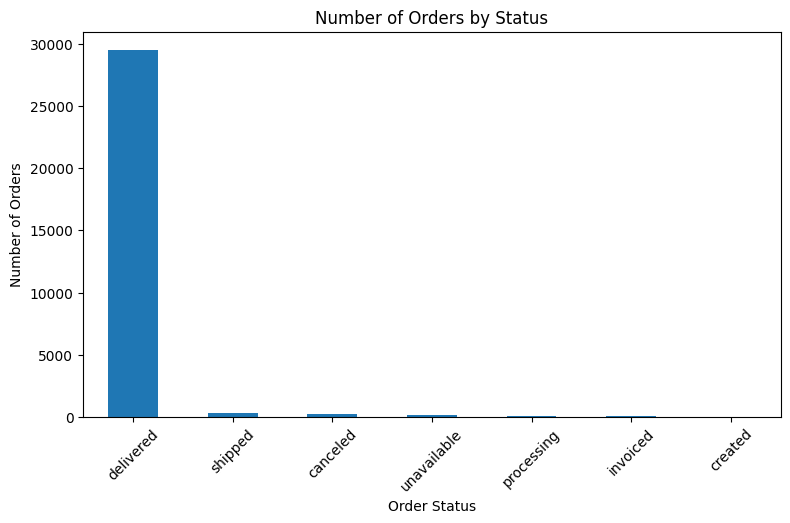

In [ ]:
order_status_count.plot(
    kind='bar',
    figsize=(9, 5),
    title='Number of Orders by Status'
)

plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

## 13. Distribution of order payment values

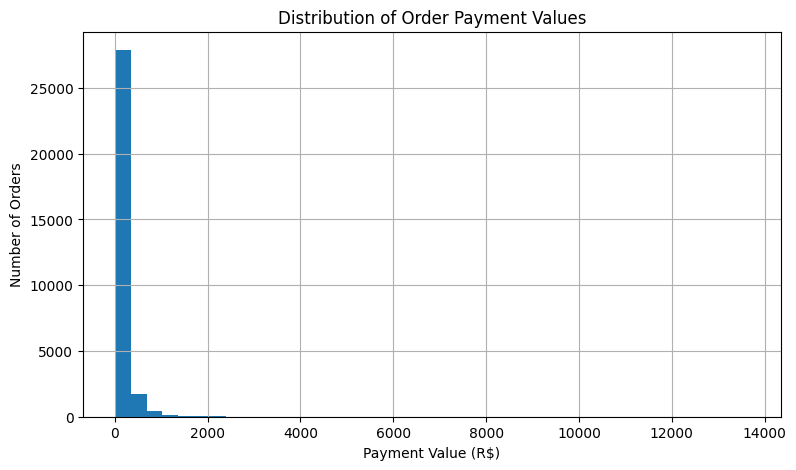

In [ ]:
df['total_payment_value'].hist(
    bins=40,
    figsize=(9, 5)
)

plt.title('Distribution of Order Payment Values')
plt.xlabel('Payment Value (R$)')
plt.ylabel('Number of Orders')
plt.show()

In [ ]:
payment_mean = df['total_payment_value'].mean()
payment_median = df['total_payment_value'].median()
payment_skew = df['total_payment_value'].skew()

print("Mean payment value:", round(payment_mean, 2))
print("Median payment value:", round(payment_median, 2))
print("Skewness:", round(payment_skew, 2))

Mean payment value: 162.47
Median payment value: 105.71
Skewness: 12.95


### Interpretation

- A positive skewness value means the distribution is **right-skewed**.
- When the mean is much larger than the median, a few high-value orders are pulling the mean upward.
- Therefore, the median is useful when describing a typical customer order.

## 14. Review score distribution

In [ ]:
review_count = df['review_score'].value_counts().sort_index()

review_count

,count
review_score,
1.0,3371
2.0,978
3.0,2472
4.0,5900
5.0,17460


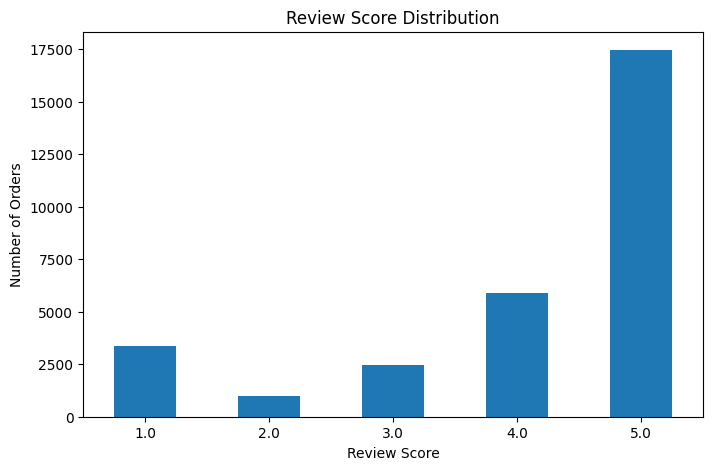

In [ ]:
review_count.plot(
    kind='bar',
    figsize=(8, 5),
    title='Review Score Distribution'
)

plt.xlabel('Review Score')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.show()

## 15. Delivery-time distribution

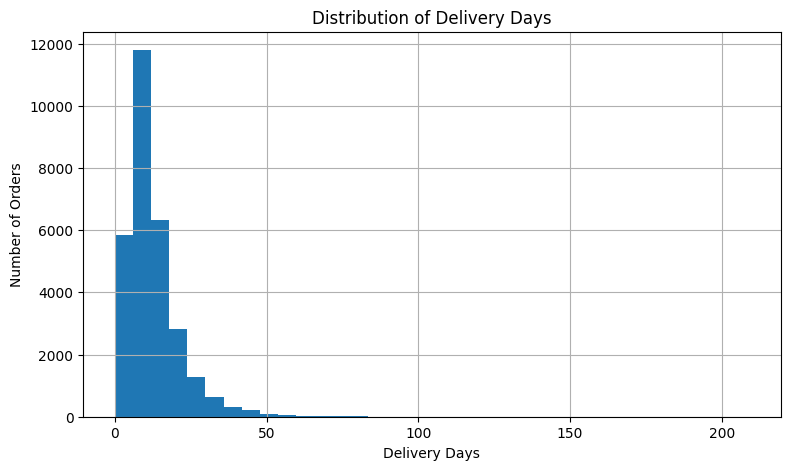

In [ ]:
df['delivery_days'].hist(
    bins=35,
    figsize=(9, 5)
)

plt.title('Distribution of Delivery Days')
plt.xlabel('Delivery Days')
plt.ylabel('Number of Orders')
plt.show()

In [ ]:
print("Average delivery days:", round(df['delivery_days'].mean(), 2))
print("Median delivery days:", round(df['delivery_days'].median(), 2))
print("Delivery-day skewness:", round(df['delivery_days'].skew(), 2))

Average delivery days: 12.03
Median delivery days: 10.0
Delivery-day skewness: 3.36


## 16. Orders and revenue by customer state

In [ ]:
state_summary = df.groupby('customer_state').agg(
    orders=('order_id', 'nunique'),
    revenue=('total_payment_value', 'sum')
)

state_summary = state_summary.sort_values(
    by='revenue',
    ascending=False
)

state_summary.head(10).round(2)

,orders,revenue
customer_state,,
SP,12908,1862117.32
RJ,4019,687532.51
MG,3506,563888.06
RS,1644,277236.68
PR,1506,255093.61
SC,1111,193216.28
BA,1014,185042.34
GO,611,111154.78
DF,605,104232.00


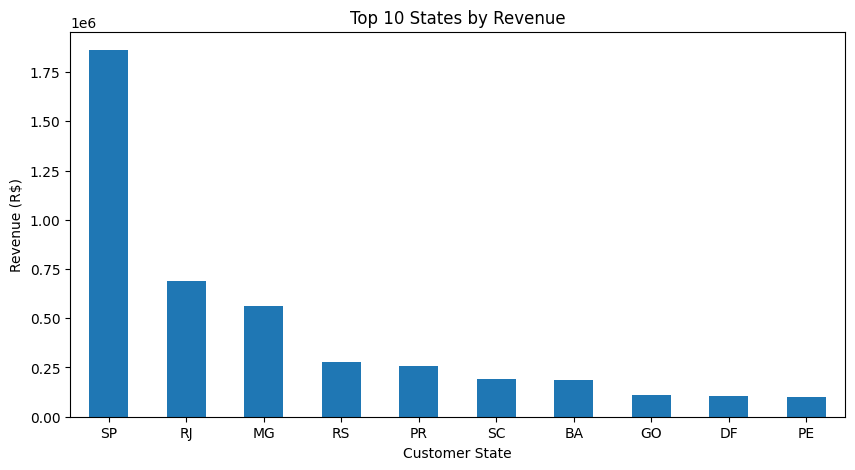

In [ ]:
state_summary.head(10)['revenue'].plot(
    kind='bar',
    figsize=(10, 5),
    title='Top 10 States by Revenue'
)

plt.xlabel('Customer State')
plt.ylabel('Revenue (R$)')
plt.xticks(rotation=0)
plt.show()

## 17. Monthly order and revenue trend

In [ ]:
df['purchase_month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)

monthly_summary = df.groupby('purchase_month').agg(
    orders=('order_id', 'nunique'),
    revenue=('total_payment_value', 'sum')
)

monthly_summary.tail()

,orders,revenue
purchase_month,,
2018-05,2114,365531.17
2018-06,1873,314527.23
2018-07,1922,334034.92
2018-08,2012,322759.66
2018-09,6,1112.84


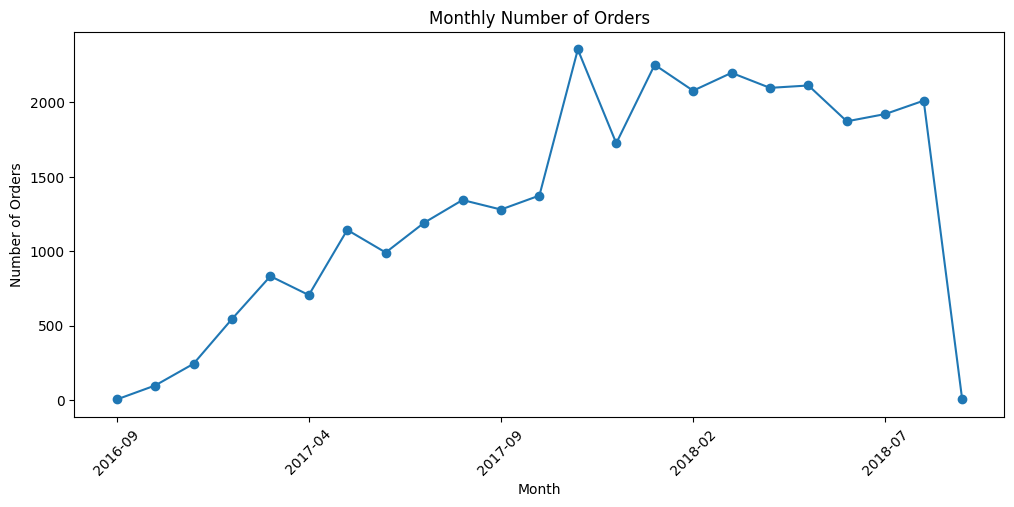

In [ ]:
monthly_summary['orders'].plot(
    figsize=(12, 5),
    marker='o',
    title='Monthly Number of Orders'
)

plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

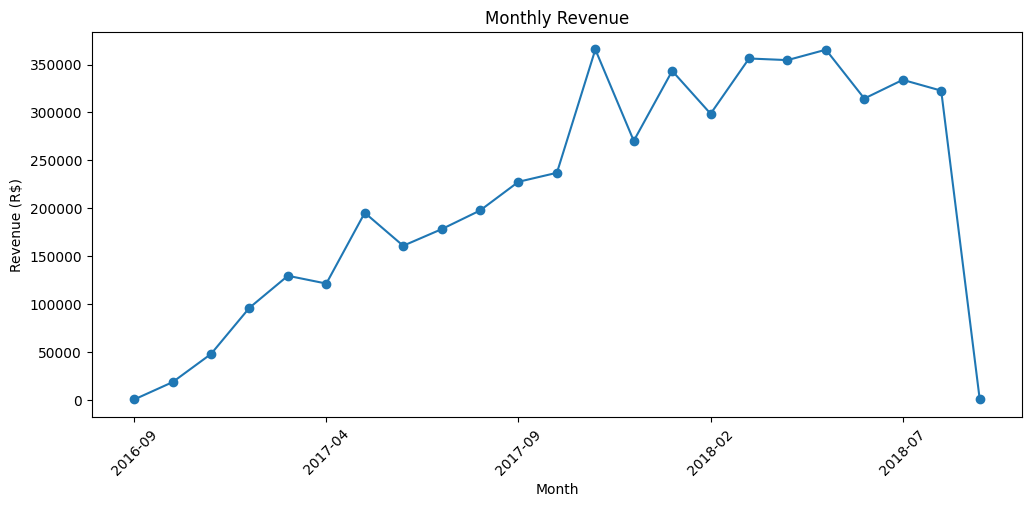

In [ ]:
monthly_summary['revenue'].plot(
    figsize=(12, 5),
    marker='o',
    title='Monthly Revenue'
)

plt.xlabel('Month')
plt.ylabel('Revenue (R$)')
plt.xticks(rotation=45)
plt.show()

## 18. Payment-method analysis

In [ ]:
# Some orders used more than one payment method.
# Split the comma-separated text and place each method on its own row.

payment_methods = df['payment_types_used'].dropna().str.split(',').explode()

payment_method_count = payment_methods.value_counts()

payment_method_count

,count
payment_types_used,
credit_card,23400
boleto,6037
voucher,1159
debit_card,492
not_defined,1


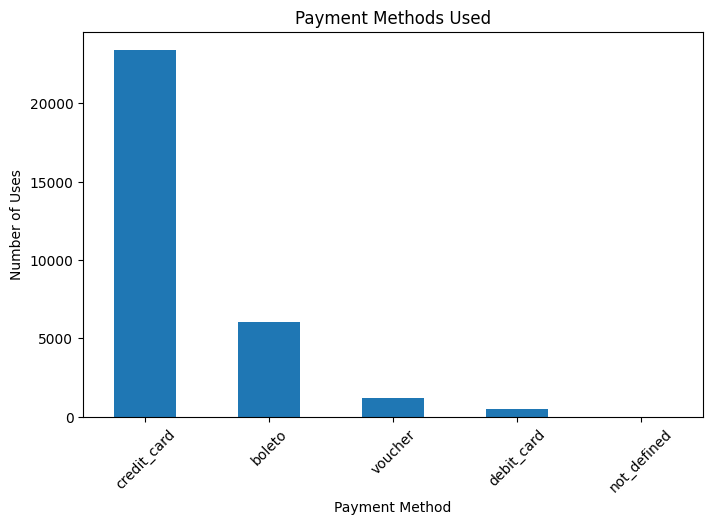

In [ ]:
payment_method_count.plot(
    kind='bar',
    figsize=(8, 5),
    title='Payment Methods Used'
)

plt.xlabel('Payment Method')
plt.ylabel('Number of Uses')
plt.xticks(rotation=45)
plt.show()

## 19. Late-delivery rate

In [ ]:
late_rate = df['is_late'].mean()

print("Late-delivery rate:", round(late_rate * 100, 2), "%")

Late-delivery rate: 6.7 %


## 20. Average review score for late and on-time orders

In [ ]:
review_by_late_status = df.groupby('is_late')['review_score'].agg([
    'count',
    'mean',
    'median'
])

review_by_late_status.round(2)

,count,mean,median
is_late,,,
False,27389,4.30,5.0
True,1934,2.27,1.0


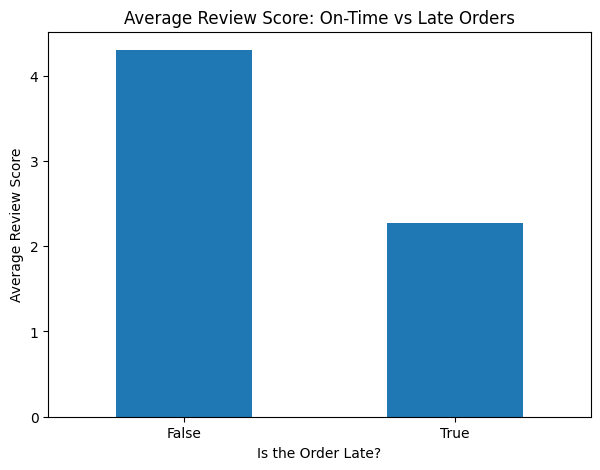

In [ ]:
review_by_late_status['mean'].plot(
    kind='bar',
    figsize=(7, 5),
    title='Average Review Score: On-Time vs Late Orders'
)

plt.xlabel('Is the Order Late?')
plt.ylabel('Average Review Score')
plt.xticks(rotation=0)
plt.show()

# Statistical Analysis

it recommends**Spearman correlation** for delivery days and review scores because:

- Review score is an ordered 1-to-5 rating.
- Delivery days is skewed.
- Spearman works with ranks and does not require a normal distribution.

## 21. Scatter plot: delivery days and review score

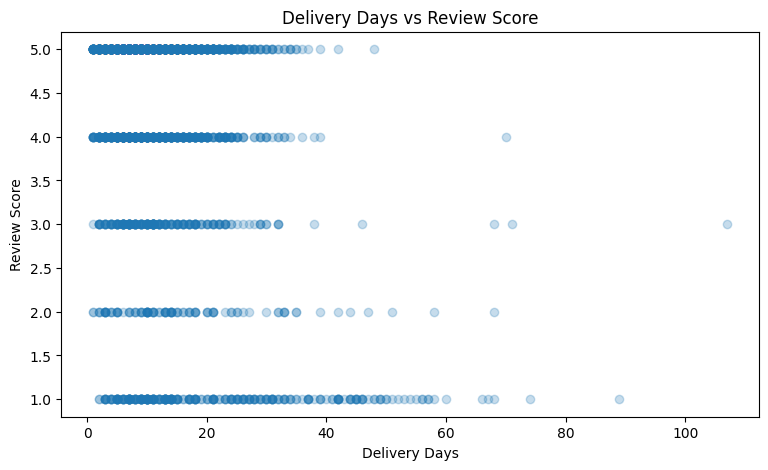

In [ ]:
plot_data = df[
    ['delivery_days', 'review_score']
].dropna()

# A smaller sample keeps the chart clear
plot_data = plot_data.sample(
    n=3000,
    random_state=42
)

plt.figure(figsize=(9, 5))
plt.scatter(
    plot_data['delivery_days'],
    plot_data['review_score'],
    alpha=0.25
)

plt.title('Delivery Days vs Review Score')
plt.xlabel('Delivery Days')
plt.ylabel('Review Score')
plt.show()

## 22. Spearman correlation test

In [ ]:
correlation_data = df[
    ['delivery_days', 'review_score']
].dropna()

spearman_r, spearman_p = spearmanr(
    correlation_data['delivery_days'],
    correlation_data['review_score']
)

print("Spearman correlation:", round(spearman_r, 3))
print("p-value:", spearman_p)

Spearman correlation: -0.227
p-value: 0.0


## 23. Chi-Square test: late delivery and low review

We create a simple category:

- `low_review = True` when review score is 1 or 2
- `low_review = False` when review score is 3, 4 or 5

Both variables are categories, so the Chi-Square test is suitable.

In [ ]:
stats_data = df[
    ['is_late', 'review_score', 'delivery_days']
].dropna().copy()

stats_data['low_review'] = stats_data['review_score'] <= 2

chi_table = pd.crosstab(
    stats_data['is_late'],
    stats_data['low_review']
)

chi_table

low_review,False,True
is_late,,
False,24907,2482
True,733,1201


In [ ]:
chi_square, chi_p, degrees_of_freedom, expected_values = chi2_contingency(
    chi_table
)

print("Chi-Square value:", round(chi_square, 2))
print("p-value:", chi_p)
print("Degrees of freedom:", degrees_of_freedom)

Chi-Square value: 4622.0
p-value: 0.0
Degrees of freedom: 1


A p-value below 0.05 means late-delivery status and low-review status are related more strongly than random chance would normally explain.

## 24. Low-review percentage for late and on-time orders

In [ ]:
low_review_rates = stats_data.groupby('is_late')['low_review'].mean()

print("On-time low-review rate:",
      round(low_review_rates[False] * 100, 2), "%")

print("Late low-review rate:",
      round(low_review_rates[True] * 100, 2), "%")

On-time low-review rate: 9.06 %
Late low-review rate: 62.1 %


## 25. Simple 95% confidence intervals

For a proportion:

- Estimated rate = number of low reviews / total orders
- Standard error uses NumPy
- The 95% interval is approximately rate ± 1.96 × standard error

This normal approximation is reasonable here because both groups are large.

In [ ]:
confidence_rows = []

for late_status in [False, True]:

    group = stats_data[
        stats_data['is_late'] == late_status
    ]

    n = len(group)
    low_review_count = group['low_review'].sum()
    rate = low_review_count / n

    standard_error = np.sqrt(
        rate * (1 - rate) / n
    )

    lower_limit = rate - 1.96 * standard_error
    upper_limit = rate + 1.96 * standard_error

    confidence_rows.append([
        late_status,
        n,
        rate,
        lower_limit,
        upper_limit
    ])

confidence_table = pd.DataFrame(
    confidence_rows,
    columns=[
        'is_late',
        'orders',
        'low_review_rate',
        'lower_95',
        'upper_95'
    ]
)

confidence_table.round(4)

,is_late,orders,low_review_rate,lower_95,upper_95
0,False,27389,0.0906,0.0872,0.0940
1,True,1934,0.6210,0.5994,0.6426


## 26. Effect size using Cohen's h

A p-value tells us whether a relationship is probably real.  
Cohen's h tells us whether the difference between the two percentages is small or large.

Common guide:

- Around 0.2 = small
- Around 0.5 = medium
- 0.8 or more = large

In [ ]:
on_time_rate = low_review_rates[False]
late_rate_review = low_review_rates[True]

cohens_h = (
    2 * np.arcsin(np.sqrt(late_rate_review))
    -
    2 * np.arcsin(np.sqrt(on_time_rate))
)

print("Cohen's h:", round(cohens_h, 3))

Cohen's h: 1.204


## 27. Mann-Whitney U test

This test compares delivery days between two review groups:

- Low reviews: score 1 or 2
- Other reviews: score 3, 4 or 5

Delivery days is skewed, so Mann-Whitney is safer than a t-test.

In [ ]:
low_review_delivery = stats_data.loc[
    stats_data['low_review'] == True,
    'delivery_days'
]

other_review_delivery = stats_data.loc[
    stats_data['low_review'] == False,
    'delivery_days'
]

mann_u, mann_p = mannwhitneyu(
    low_review_delivery,
    other_review_delivery,
    alternative='two-sided'
)

print("Median delivery days for low reviews:",
      low_review_delivery.median())

print("Median delivery days for other reviews:",
      other_review_delivery.median())

print("Mann-Whitney U value:", mann_u)
print("p-value:", mann_p)

Median delivery days for low reviews: 15.0
Median delivery days for other reviews: 9.0
Mann-Whitney U value: 64594807.0
p-value: 2.3817282388316022e-287


## 28. Simple multiple-testing correction

We performed three main tests.  
When many tests are run, the chance of a false positive increases.

A simple Bonferroni correction multiplies each p-value by the number of tests.

In [ ]:
test_results = pd.DataFrame({
    'test': [
        'Spearman correlation',
        'Chi-Square',
        'Mann-Whitney U'
    ],
    'p_value': [
        spearman_p,
        chi_p,
        mann_p
    ]
})

number_of_tests = len(test_results)

test_results['adjusted_p_value'] = np.minimum(
    test_results['p_value'] * number_of_tests,
    1
)

test_results

,test,p_value,adjusted_p_value
0,Spearman correlation,0.000000e+00,0.000000e+00
1,Chi-Square,0.000000e+00,0.000000e+00
2,Mann-Whitney U,2.381728e-287,7.145185e-287


## 29. Statistical power note

The late and on-time groups both contain thousands of observations.  
Therefore, low statistical power is unlikely to be the main problem here.

Because the sample is large, we should not rely only on very small p-values.  
We must also report:

- The actual percentage difference
- Confidence intervals
- Effect size

# RFM Customer Analysis

RFM means:

- **Recency:** How recently the customer purchased
- **Frequency:** How many different orders the customer placed
- **Monetary:** How much money the customer spent

## 30. Keep delivered orders for RFM

In [ ]:
delivered_orders = df[
    df['order_status'] == 'delivered'
].copy()

print("Delivered orders:", len(delivered_orders))

Delivered orders: 29499


## 31. Create the RFM table

In [ ]:
snapshot_date = (
    delivered_orders['order_purchase_timestamp'].max()
    +
    pd.Timedelta(days=1)
)

rfm = delivered_orders.groupby(
    'customer_unique_id'
).agg(
    recency=(
        'order_purchase_timestamp',
        lambda dates: (snapshot_date - dates.max()).days
    ),
    frequency=(
        'order_id',
        'nunique'
    ),
    monetary=(
        'total_payment_value',
        'sum'
    )
).reset_index()

rfm.head()

,customer_unique_id,recency,frequency,monetary
0,0000f46a3911fa3c0805444483337064,537,1,86.22
1,00053a61a98854899e70ed204dd4bafe,183,1,419.18
2,0006fdc98a402fceb4eb0ee528f6a8d4,408,1,29.00
3,00082cbe03e478190aadbea78542e933,283,1,126.26
4,00090324bbad0e9342388303bb71ba0a,158,1,63.66


## 32. Look at the RFM summary

In [ ]:
rfm[['recency', 'frequency', 'monetary']].describe().round(2)

,recency,frequency,monetary
count,29170.00,29170.00,29170.00
mean,239.08,1.01,163.70
std,152.66,0.11,237.74
min,1.00,1.00,10.07
25%,115.00,1.00,62.99
50%,220.00,1.00,106.72
75%,348.00,1.00,178.80
max,695.00,6.00,13664.08


In [ ]:
frequency_count = rfm['frequency'].value_counts().sort_index()

frequency_count.head(10)

,count
frequency,
1,28858
2,300
3,10
4,1
6,1


Most Olist customers purchased only once.  
Therefore, frequency has limited variation, and this limitation should be clearly mentioned.

## 33. Create simple RFM scores

In [ ]:
# Recent customers receive a higher recency score
rfm['R_score'] = pd.qcut(
    rfm['recency'].rank(method='first'),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

# High-spending customers receive a higher monetary score
rfm['M_score'] = pd.qcut(
    rfm['monetary'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Because most customers buy once, use a simple frequency rule
rfm['F_score'] = 1
rfm.loc[rfm['frequency'] >= 2, 'F_score'] = 5

rfm.head()

,customer_unique_id,recency,frequency,monetary,R_score,M_score,F_score
0,0000f46a3911fa3c0805444483337064,537,1,86.22,1,2,1
1,00053a61a98854899e70ed204dd4bafe,183,1,419.18,3,5,1
2,0006fdc98a402fceb4eb0ee528f6a8d4,408,1,29.00,1,1,1
3,00082cbe03e478190aadbea78542e933,283,1,126.26,2,3,1
4,00090324bbad0e9342388303bb71ba0a,158,1,63.66,4,2,1


## 34. Create easy-to-understand customer segments

In [ ]:
rfm['segment'] = 'Other Customers'

rfm.loc[
    rfm['frequency'] >= 2,
    'segment'
] = 'Repeat Customers'

rfm.loc[
    (rfm['R_score'] <= 2) &
    (rfm['M_score'] >= 4),
    'segment'
] = 'At Risk'

rfm.loc[
    (rfm['R_score'] >= 4) &
    (rfm['M_score'] >= 4),
    'segment'
] = 'Champions'

segment_count = rfm['segment'].value_counts()

segment_count

,count
segment,
Other Customers,19672
Champions,4774
At Risk,4606
Repeat Customers,118


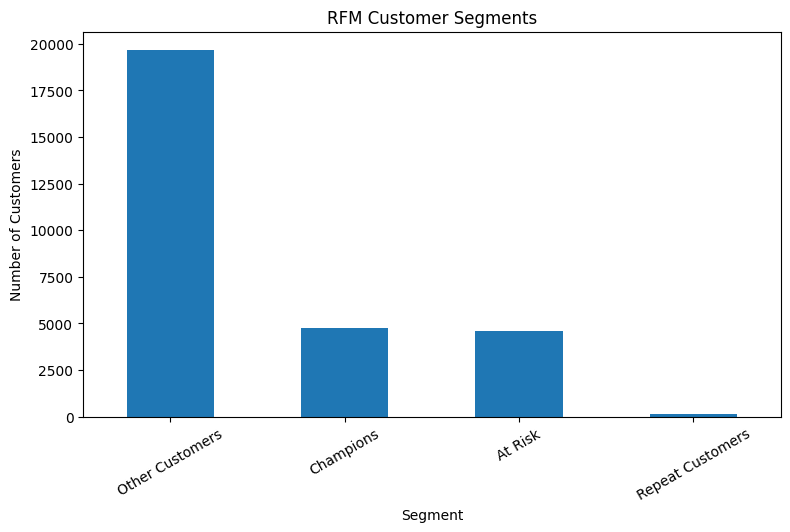

In [ ]:
segment_count.plot(
    kind='bar',
    figsize=(9, 5),
    title='RFM Customer Segments'
)

plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
plt.show()

### Segment meaning

- **Champions:** Recent customers who also spent a high amount
- **Repeat Customers:** Customers who placed at least two orders
- **At Risk:** Previously valuable customers who have not purchased recently
- **Other Customers:** Customers who do not yet fit the above groups

# Pareto Revenue Analysis




**What percentage of total revenue comes from the top 20% of customers?**

## 35. Sort customers by revenue

In [ ]:
customer_revenue = rfm[
    ['customer_unique_id', 'monetary']
].sort_values(
    by='monetary',
    ascending=False
).reset_index(drop=True)

customer_revenue.head()

,customer_unique_id,monetary
0,0a0a92112bd4c708ca5fde585afaa872,13664.08
1,dc4802a71eae9be1dd28f5d788ceb526,6929.31
2,459bef486812aa25204be022145caa62,6922.21
3,ff4159b92c40ebe40454e3e6a7c35ed6,6726.66
4,edde2314c6c30e864a128ac95d6b2112,4513.32


## 36. Calculate cumulative customer and revenue percentages

In [ ]:
customer_revenue['customer_number'] = (
    customer_revenue.index + 1
)

customer_revenue['customer_percentage'] = (
    customer_revenue['customer_number']
    /
    len(customer_revenue)
)

customer_revenue['cumulative_revenue'] = (
    customer_revenue['monetary'].cumsum()
)

customer_revenue['revenue_percentage'] = (
    customer_revenue['cumulative_revenue']
    /
    customer_revenue['monetary'].sum()
)

customer_revenue.head()

,customer_unique_id,monetary,customer_number,customer_percentage,cumulative_revenue,revenue_percentage
0,0a0a92112bd4c708ca5fde585afaa872,13664.08,1,0.000034,13664.08,0.002861
1,dc4802a71eae9be1dd28f5d788ceb526,6929.31,2,0.000069,20593.39,0.004313
2,459bef486812aa25204be022145caa62,6922.21,3,0.000103,27515.60,0.005762
3,ff4159b92c40ebe40454e3e6a7c35ed6,6726.66,4,0.000137,34242.26,0.007171
4,edde2314c6c30e864a128ac95d6b2112,4513.32,5,0.000171,38755.58,0.008116


## 37. Revenue share from the top 20% of customers

In [ ]:
top_20_count = int(
    len(customer_revenue) * 0.20
)

top_20_revenue = customer_revenue.iloc[
    :top_20_count
]['monetary'].sum()

total_customer_revenue = customer_revenue[
    'monetary'
].sum()

top_20_share = (
    top_20_revenue
    /
    total_customer_revenue
)

print("Number of customers in top 20%:", top_20_count)
print("Revenue share from top 20%:",
      round(top_20_share * 100, 2), "%")

Number of customers in top 20%: 5834
Revenue share from top 20%: 53.59 %


## 38. Pareto curve

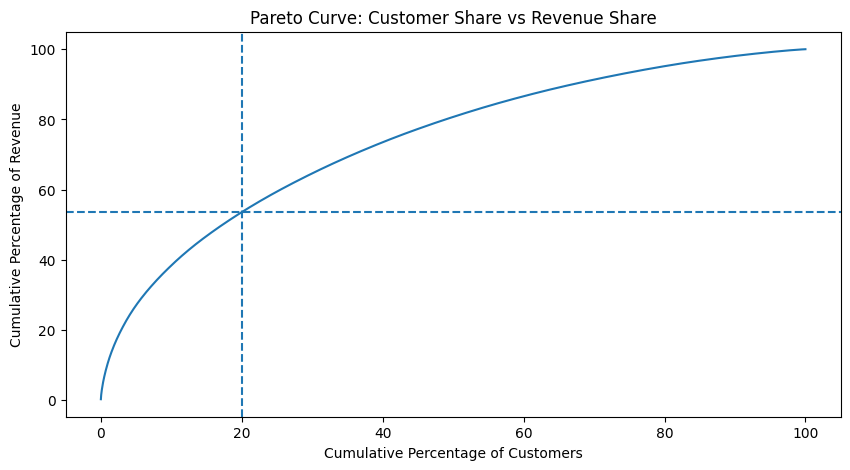

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    customer_revenue['customer_percentage'] * 100,
    customer_revenue['revenue_percentage'] * 100
)

plt.axvline(
    x=20,
    linestyle='--'
)

plt.axhline(
    y=top_20_share * 100,
    linestyle='--'
)

plt.title('Pareto Curve: Customer Share vs Revenue Share')
plt.xlabel('Cumulative Percentage of Customers')
plt.ylabel('Cumulative Percentage of Revenue')
plt.show()

# Final Conclusion

Use the outputs above to write your final result in this form:

1. The data contains one row per order, so order-level revenue is not duplicated.
2. Payment value is right-skewed, so both mean and median should be reported.
3. Longer delivery time is linked to lower review scores.
4. Late orders have a much higher low-review rate than on-time orders.
5. The statistical tests show a real relationship, while confidence intervals and effect size show its practical size.
6. Most customers bought only once, so frequency is weak in this dataset.
7. A smaller group of customers contributes a large share of total revenue.
8. The relationship between delivery and reviews is observational and should not be described as definite causation.

# Limitations

- The file is already cleaned and joined, so the original table-joining process cannot be demonstrated again.
- `seller_id` and product-category columns are not available.
- Pareto analysis is therefore performed on customers instead of sellers.
- Review scores are ordinal ratings, so Spearman correlation is preferred.
- Correlation and association do not prove causation.